## purpose of this notebook

Redo the mapping notebook to see where these terms are taking place in the miniASTE
Try to look at the previous mapping notebook to get a how-to guide.

In [1]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")
from scipy.ndimage import binary_dilation

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

(450, 90)
RAC2d (40500,)
(100,)


In [2]:
# we need to load the miniaste
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [3]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

In [4]:
# make the 3d mask here
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))

In [5]:
# we need to also redefine landmsk
landmsk = mygrid['hFacC'][0]
landmsk = np.where(np.isnan(landmsk), 1.0, np.nan)
print(landmsk.shape)

(450, 90)


(140.0, 190.0)

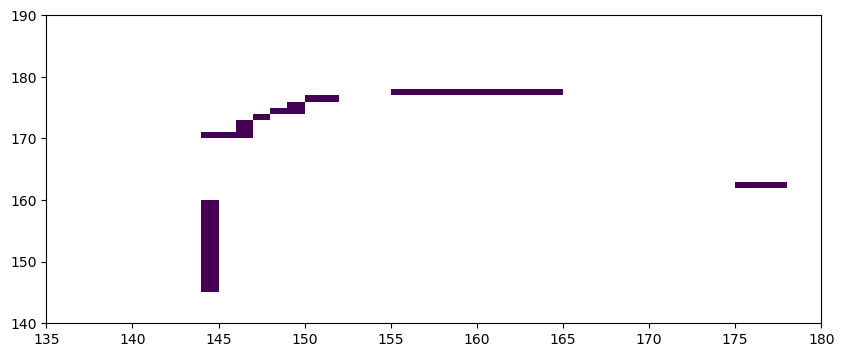

In [24]:
# we should also create a small mask for the gates here
# create the gate terms and prove the same figure as in the 1/20 meeting


def _mark_points(mask, xs, ys, code, ny, nx, name="gate"):
    """
    Mark (y, x) points in mask with 'code'.
    If a point already has a different non-NaN code, set it to 3 (overlap).
    Bounds are clipped to the grid silently.
    """
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    if xs.shape != ys.shape:
        raise ValueError(f"{name}: x/y length mismatch: {xs.shape} vs {ys.shape}")

    # clip to valid indices just in case
    xi = np.clip(xs.astype(int), 0, nx-1)
    yi = np.clip(ys.astype(int), 0, ny-1)

    for j, i in zip(yi, xi):
        cur = mask[j, i]
        if np.isnan(cur):
            mask[j, i] = code
        elif cur == code or cur == 3:
            # already same code or already overlap — leave as is
            continue
        else:
            mask[j, i] = 3  # overlap with different code
    return mask

# these are the indices we want to read from, but not write to
# at y = 186, we want -ADVy
x_bsoh = np.array([54, 54, 54, 54, 54])
x_bsov = np.array([0,  1,  2,  3,  4,  5,  6,  7,  8,  9])    # from Norway to Sp
y_bsoh = np.array([145, 146, 147, 148, 149])
y_bsov = np.array([185, 185, 185, 185, 185, 185, 185, 185, 185, 185])    # from Norway to Sp

x_spfjh = np.array([20,20,20,23,24,24,26,26])    # vertical gates from Sp to Fj as -x
y_spfjh = np.array([185,184,183,182,181,180,179,178])
x_spfjv = np.array([20,21,22,23,24,25,26])          # horizontal gates where we want to read -y
y_spfjv = np.array([183,183,183,183,182,180,180])

y_fjnzv = np.arange(165,175,1)
x_fjnzv = np.full_like(y_fjnzv,27)    # horizontal gate where we want to read -x

y_nzruv = np.arange(152,155,1)
x_nzruv = np.full_like(y_nzruv,12)   # horizontal gate where we want to read -x

# gates_mask starts as NaN everywhere
gates_mask = np.full((ny, nx), np.nan, dtype=float)

# ---- mark H gates with code = 1 ----
gates_mask = _mark_points(gates_mask, x_bsoh, y_bsoh, 1, ny, nx, name="bsoh")
gates_mask = _mark_points(gates_mask, x_spfjh, y_spfjh, 1, ny, nx, name="spfjh")

# ---- mark V gates with code = 2 ----
gates_mask = _mark_points(gates_mask, x_bsov,  y_bsov,  1, ny, nx, name="bsov")
gates_mask = _mark_points(gates_mask, x_spfjv, y_spfjv, 1, ny, nx, name="spfjv")
gates_mask = _mark_points(gates_mask, x_fjnzv, y_fjnzv, 1, ny, nx, name="fjnzv")
gates_mask = _mark_points(gates_mask, x_nzruv, y_nzruv, 1, ny, nx, name="nzruv")

# Optional: if you prefer 0 instead of NaN for “not a gate”
# gates_mask = np.nan_to_num(gates_mask, nan=0.0)

# let's make a mask of these to double check that we did this correctly
gates_mask[182,23] = 1
gates_mask[180,24] = 1 
gates_mask[180,26] = np.nan
gates_mask[182,24] = np.nan
gates_mask[183,23] = np.nan


testmsk = gates_mask.copy()
testmsk[:,:19] = np.nan
testmsk[:,30:] = np.nan
testmsk[:178,:] = np.nan
y_spfjv2,x_spfjv2 = np.where(testmsk == 2)[0],np.where(testmsk == 2)[1]
y_spfjh2,x_spfjh2 = np.where(testmsk == 1)[0],np.where(testmsk == 1)[1]
y_spfjb2,x_spfjb2 = np.where(testmsk == 3)[0],np.where(testmsk == 3)[1]
RAC = mygrid['RAC']

plt.pcolormesh(get_aste_tracer(gates_mask,nfx,nfy)[0])
gates_data = get_aste_tracer(gates_mask,nfx,nfy)[0]
plt.xlim(135,180)
plt.ylim(140,190)

# we need to effectively run the same items we had in create_aste90_layers to get the values

In [6]:
# load the tsstr that we want and the mask we want

tsstr = np.array(["0000000002","0000000003"])
t2 = int(tsstr[1]) # for the offline version

In [7]:
from create_aste90_layers import create_layers_totalTHETA  # ,create_layers_totalSALT

In [8]:
# load the TS bins
# also load the bins again so we have them locally
boundsT = np.round(np.squeeze(rdmds(layers_path + "layers2TH")).ravel(),1)
nT = boundsT.size - 1
boundsS = np.round(np.squeeze(rdmds(layers_path + "layers1SLT")).ravel(),1)
nS = boundsS.size - 1
binwidthT = boundsT[1:] - boundsT[:-1]
binwidthS = boundsS[1:] - boundsS[:-1]
binwidthT1 = 0.5 * (binwidthT[1:] + binwidthT[:-1])  # normalize by these
binwidthS1 = 0.5 * (binwidthS[1:] + binwidthS[:-1])
binmidT = (boundsT[1:] + boundsT[:-1]) /2    # bin to these
binmidS = (boundsS[1:] + boundsS[:-1]) /2
nT = nT
nS = nS
nTm1 = nT-1
nSm1 = nS-1

In [9]:
dt = 1800

In [10]:
t2 = int(tsstr[1])
# 'diags/state_3d_set1'
# read theta and salt averages from the t2 timestep (average)
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz,ny,nx)
SALT = SALT.reshape(nz,ny,nx)

In [11]:
termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=True)

### create maps of the primary terms at 3 diff depth levels

In [12]:
# load the SI edge at this map
# dirstate
# diags/state_2d_set1'

t2 = int(tsstr[1])
# 'diags/state_3d_set1'
# read theta and salt averages from the t2 timestep (average)
file_name = "state_2d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["SIarea"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
SIarea,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])

SIarea = SIarea.reshape(ny,nx)

In [13]:

def mean_SI_masked(
    tsstr, *,
    dirState, ny, nx, nfx, nfy,
    landmsk, mymsk,
    file_name="state_2d_set1",
    varname="SIarea",
    land_buffer_iters=1,
):
    """
    Same outputs as before, but reads SIarea using your pattern:
      - parse meta from tsstr[0]
      - find rec index for "SIarea"
      - for each month-pair, read timestep t2 = int(tsstr[i+1]) via rdmds(..., t2, rec=rec)
    """
    tsstr = list(tsstr)
    if len(tsstr) < 2:
        raise ValueError("Need at least 2 timesteps to form one monthly field.")
    npairs = len(tsstr) - 1

    # --- parse meta once to find record index (your pattern) ---
    meta_state = parsemeta(os.path.join(dirState, f"{file_name}.{tsstr[0]}.meta"))
    fldlist = np.array(meta_state["fldList"])
    idx = np.where(fldlist == varname)[0]
    if idx.size == 0:
        raise KeyError(f"{varname} not in fldList. Available: {list(fldlist)}")
    rec = int(idx[0])

    # --- land buffer mask on tracer grid (constant across time) ---
    landmask_tr = (get_aste_tracer(landmsk, nfx, nfy)[0] > 0)
    landbuffer_tr = binary_dilation(landmask_tr, iterations=land_buffer_iters)

    acc_tr = None
    acc_masked_tr = None
    cnt_tr = None
    cnt_masked = None

    pairs = []
    for i in range(npairs):
        t1 = tsstr[i]
        t2 = int(tsstr[i + 1])
        pairs.append((t1, str(t2)))

        # --- read SIarea exactly like your snippet (no read=[...]) ---
        SIarea, its, meta = rdmds(
            os.path.join(dirState, file_name),
            t2,
            returnmeta=True,
            rec=rec
        )
        SIarea = np.asarray(SIarea).reshape((ny, nx))
        #print(SIarea.shape)

        # map to tracer-tile
        SI_tr = get_aste_tracer(SIarea, nfx, nfy)[0]
        #print(SI_tr.shape)

        # apply land-buffer mask
        SI_masked = np.where(landbuffer_tr, np.nan, SI_tr)

        if acc_tr is None:
            acc_tr = np.zeros_like(SI_tr, dtype=np.float64)
            acc_masked_tr = np.zeros_like(SI_tr, dtype=np.float64)
            cnt_tr = np.zeros_like(SI_tr, dtype=np.float64)
            cnt_masked = np.zeros_like(SI_tr, dtype=np.float64)

        ok = np.isfinite(SI_tr)
        acc_tr[ok] += SI_tr[ok]
        cnt_tr[ok] += 1.0

        okm = np.isfinite(SI_masked)
        acc_masked_tr[okm] += SI_masked[okm]
        cnt_masked[okm] += 1.0

    SI_mean_tr = acc_tr / np.where(cnt_tr > 0, cnt_tr, np.nan)
    SI_masked_mean_tr = acc_masked_tr / np.where(cnt_masked > 0, cnt_masked, np.nan)

    meta_out = {
        "ts_list": tsstr,
        "pairs": pairs,
        "npairs": npairs,
        "read_second_of_pair": True,
        "rec": rec,
        "varname": varname,
        "file_name": file_name,
    }
    return SI_masked_mean_tr, SI_mean_tr, meta_out


# -------------------------
# Example: JFM mean SI for 2007
# (need Jan..Apr timesteps so you can form 3 monthly fields)
# -------------------------

SI_contour, SI_JFM, metaSI = mean_SI_masked(
    tsstr,
    dirState=dirstate, ny=ny, nx=nx, nfx=nfx, nfy=nfy,
    landmsk=landmsk, mymsk=mymsk,  # mymsk not used here except you might want it later
    land_buffer_iters=1,
)
# this is fine and will work with however many timesteps we have

In [14]:
# we need to retrieve the terms from the heat budget
maxdepth = 100

# indices for z where cumulative depth < maxdepth
# (use the 1D index array explicitly)
kinds = np.where(np.cumsum(mygrid['DRF']) < maxdepth)[0]

# depth-mean of the term over top maxdepth
toplot = termsT3D['DFhT'][kinds, :, :]          # (k, y, x)
toplot2d = np.nanmean(toplot, axis=0)          # (y, x)
toplot_asplt = get_aste_tracer(toplot2d, nfx, nfy)[0]

# land + theta on tracer tile
land_data = get_aste_tracer(landmsk, nfx, nfy)[0]
depth_data = get_aste_tracer(mygrid["Depth"], nfx, nfy)[0]
theta2d = np.nanmean(THETA[kinds, :, :], axis=0)
theta_asplt = get_aste_tracer(theta2d, nfx, nfy)[0]
# thin depth contours
depth_levels = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
depth_levels = [100, 200, 300, 400, 500]

depth_contour_kw = dict(colors="k", linewidths=0.6, alpha=0.55, zorder=9)

/tmp/ipykernel_1974304/4042143012.py:10: RuntimeWarning: Mean of empty slice
  toplot2d = np.nanmean(toplot, axis=0)          # (y, x)


In [54]:

from matplotlib import colors

def plot_terms(
    tracer3d, terms3d, term_key, *,
    mygrid, nfx, nfy,
    SI_contour=None,
    landmsk=None,
    mymsk=None,
    z1=0, z2=100,
    depth_levels=(50, 100, 150, 200, 250, 300, 350, 400, 450, 500),
    depth_contour_kw=None,
    cmap_tracer="seismic",
    cmap_term="seismic",
    term_symmetric=True,
    tracer_center0=False,
    tracer_step=0.5,              # <-- NEW: bin size for tracer
    tracer_discrete=True,         # <-- NEW: turn on discrete bins
    xlim=None, ylim=None,
    tracer_label="",
    term_label=None,
    figsize=(12, 5),
    si_label="SI-edge",
    si_label_loc="bottom_right",
    si_label_axes_xy=(0.98, 0.02),
    gates_data=None,              # (optional) already on tracer tile
):
    if depth_contour_kw is None:
        depth_contour_kw = dict(colors="k", linewidths=0.6, alpha=0.55, zorder=9)
    if term_label is None:
        term_label = term_key

    zc = np.cumsum(np.asarray(mygrid["DRF"]).ravel())
    kinds = np.where((zc > z1) & (zc <= z2))[0]
    if kinds.size == 0:
        raise ValueError(f"No vertical levels found for z1={z1}, z2={z2}.")

    tracer2d = np.nanmean(tracer3d[kinds, :, :], axis=0)
    term2d   = np.nanmean(terms3d[term_key][kinds, :, :], axis=0)

    tracer_asplt = get_aste_tracer(tracer2d, nfx, nfy)[0]
    term_asplt   = get_aste_tracer(term2d,   nfx, nfy)[0]
    depth_data   = get_aste_tracer(mygrid["Depth"], nfx, nfy)[0]

    land_data = None
    if landmsk is not None:
        landmsk_arr = np.asarray(landmsk)
        land_data = landmsk_arr if landmsk_arr.shape == tracer_asplt.shape else get_aste_tracer(landmsk_arr, nfx, nfy)[0]

    tracer_lim_field = tracer2d * mymsk if mymsk is not None else tracer2d
    term_lim_field   = term2d   * mymsk if mymsk is not None else term2d

    # ---- tracer limits
    if tracer_center0:
        mT = np.nanmax(np.abs(tracer_lim_field))
        vminT, vmaxT = -mT, mT
    else:
        vminT, vmaxT = np.nanmin(tracer_lim_field), np.nanmax(tracer_lim_field)

    # ---- build discrete bins for tracer (0.5 by default)
    tracer_norm = None
    tracer_ticks = None
    if tracer_discrete:
        lo = np.floor(vminT / tracer_step) * tracer_step
        hi = np.ceil(vmaxT / tracer_step) * tracer_step
        bounds = np.arange(lo, hi + tracer_step, tracer_step)
        tracer_norm = colors.BoundaryNorm(bounds, ncolors=plt.get_cmap(cmap_tracer).N, clip=True)
        tracer_ticks = bounds  # or bounds[::2] if too many

    # ---- term limits
    if term_symmetric:
        mQ = np.nanmax(np.abs(term_lim_field))
        vminQ, vmaxQ = -mQ, mQ
    else:
        vminQ, vmaxQ = np.nanmin(term_lim_field), np.nanmax(term_lim_field)

    fig = plt.figure(figsize=figsize)

    # ---- left
    axL = plt.subplot(121)
    im1 = axL.pcolormesh(
        tracer_asplt,
        cmap=cmap_tracer,
        norm=tracer_norm,          # <-- discrete if enabled
        vmin=None if tracer_norm else vminT,
        vmax=None if tracer_norm else vmaxT,
    )
    if land_data is not None:
        axL.pcolormesh(land_data, cmap="Greys", zorder=7, vmin=0, vmax=6)
    if SI_contour is not None:
        axL.contour(SI_contour, levels=[0.15], colors="lightgreen",
                    linewidths=1.5, linestyles="--", zorder=10)
    axL.contour(depth_data, levels=list(depth_levels), **depth_contour_kw)
    if gates_data is not None:
        axL.pcolormesh(gates_data, cmap="Greys", vmin=0, vmax=2, alpha=0.8)
    axL.set_aspect("equal", adjustable="box")
    axL.set_title(f"Mean {tracer_label or 'tracer'} ({z1}–{z2} m)")
    if xlim is not None: axL.set_xlim(*xlim)
    if ylim is not None: axL.set_ylim(*ylim)

    cb1 = plt.colorbar(im1, ax=axL, fraction=0.046, pad=0.04, label=tracer_label or "tracer")
    if tracer_discrete and tracer_ticks is not None:
        cb1.set_ticks(tracer_ticks)

    # ---- right
    axR = plt.subplot(122)
    im2 = axR.pcolormesh(term_asplt, cmap=cmap_term, vmin=vminQ, vmax=vmaxQ)
    if land_data is not None:
        axR.pcolormesh(land_data, cmap="Greys", zorder=7, vmin=0, vmax=6)
    si_cs = None
    if SI_contour is not None:
        si_cs = axR.contour(SI_contour, levels=[0.15], colors="lightgreen",
                            linewidths=1.5, linestyles="--", zorder=10)
    axR.contour(depth_data, levels=list(depth_levels), **depth_contour_kw)
    if gates_data is not None:
        axR.pcolormesh(gates_data, cmap="Greys", vmin=0, vmax=2, alpha=0.8)
    axR.set_aspect("equal", adjustable="box")
    axR.set_title(f"{term_label} depth-mean ({z1}–{z2} m)")
    if xlim is not None: axR.set_xlim(*xlim)
    if ylim is not None: axR.set_ylim(*ylim)
    plt.colorbar(im2, ax=axR, fraction=0.046, pad=0.04, label=term_label)

    # ---- label the SI contour on bottom-right of right plot
    if si_cs is not None and si_label:
        xy = (0.98, 0.02) if si_label_loc == "bottom_right" else si_label_axes_xy
        axR.text(
            xy[0], xy[1], si_label,
            transform=axR.transAxes,
            ha="right", va="bottom",
            fontsize=10,
            color="lightgreen",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.6),
            zorder=20
        )

    plt.tight_layout()
    return fig, (axL, axR), dict(
        kinds=kinds, vminT=vminT, vmaxT=vmaxT, vminQ=vminQ, vmaxQ=vmaxQ,
        tracer_step=tracer_step, tracer_discrete=tracer_discrete
    )


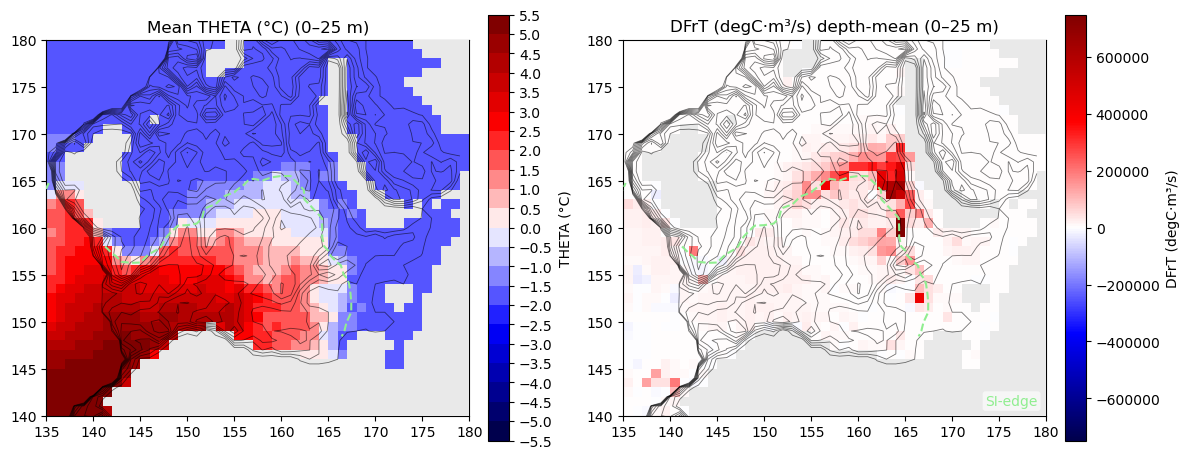

In [55]:
term_key = "DFrT"
fig, axes, out = plot_terms(
    tracer3d=THETA,
    terms3d=termsT3D,
    term_key=term_key,
    mygrid=mygrid, nfx=nfx, nfy=nfy,
    SI_contour=SI_contour, landmsk=landmsk, mymsk=mymsk,
    z1=0, z2=25,
    xlim=(135,180), ylim=(140,180),
    tracer_label="THETA (°C)",
    term_label=term_key + " (degC·m³/s)",
    tracer_center0=True,          # centers tracer colorbar at 0
)


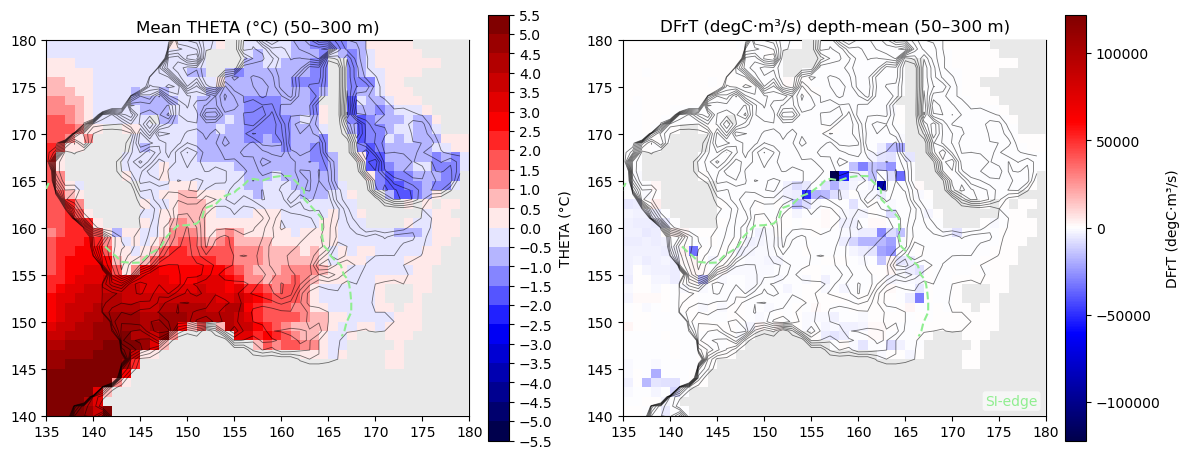

In [56]:
term_key = "DFrT"
fig, axes, out = plot_terms(
    tracer3d=THETA,
    terms3d=termsT3D,
    term_key=term_key,
    mygrid=mygrid, nfx=nfx, nfy=nfy,
    SI_contour=SI_contour, landmsk=landmsk, mymsk=mymsk,
    z1=50, z2=300,
    xlim=(135,180), ylim=(140,180),
    tracer_label="THETA (°C)",
    term_label=term_key + " (degC·m³/s)",
    tracer_center0=True,          # centers tracer colorbar at 0
)


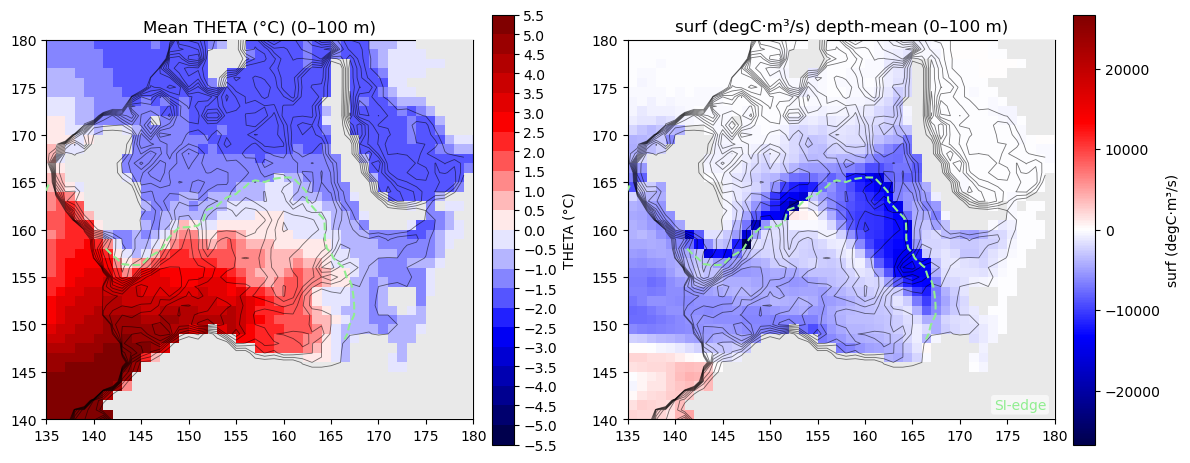

In [57]:
term_key = "surf"
fig, axes, out = plot_terms(
    tracer3d=THETA,
    terms3d=termsT3D,
    term_key=term_key,
    mygrid=mygrid, nfx=nfx, nfy=nfy,
    SI_contour=SI_contour, landmsk=landmsk, mymsk=mymsk,
    z1=0, z2=100,
    xlim=(135,180), ylim=(140,180),
    tracer_label="THETA (°C)",
    term_label=term_key + " (degC·m³/s)",
    tracer_center0=True,          # centers tracer colorbar at 0
)


/tmp/ipykernel_1974304/3152749955.py:38: RuntimeWarning: Mean of empty slice
  term2d   = np.nanmean(terms3d[term_key][kinds, :, :], axis=0)


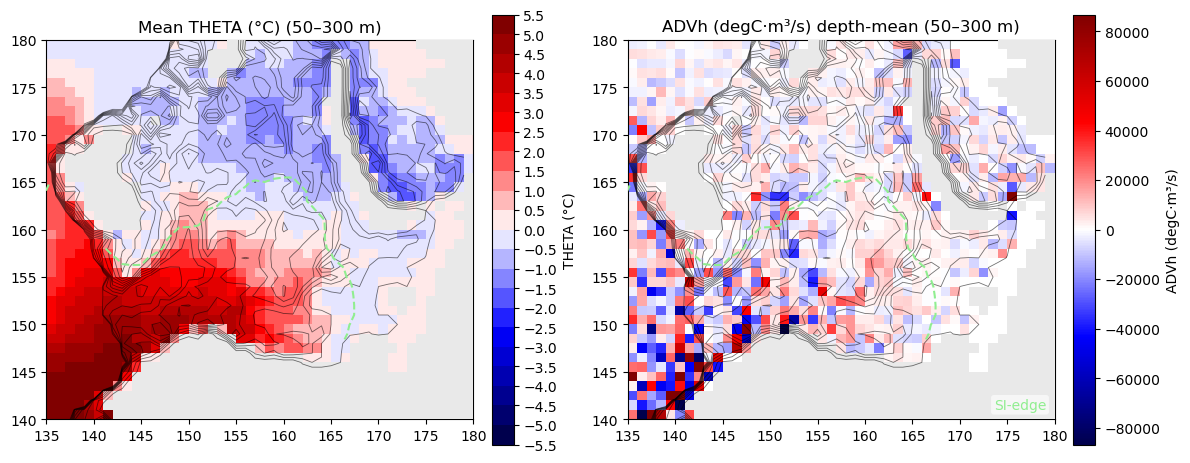

In [62]:
term_key = "ADVh"
fig, axes, out = plot_terms(
    tracer3d=THETA,
    terms3d=termsT3D,
    term_key=term_key,
    mygrid=mygrid, nfx=nfx, nfy=nfy,
    SI_contour=SI_contour, landmsk=landmsk, mymsk=mymsk,
    z1=50, z2=300,
    xlim=(135,180), ylim=(140,180),
    tracer_label="THETA (°C)",
    term_label=term_key + " (degC·m³/s)",
    tracer_center0=True,          # centers tracer colorbar at 0
)


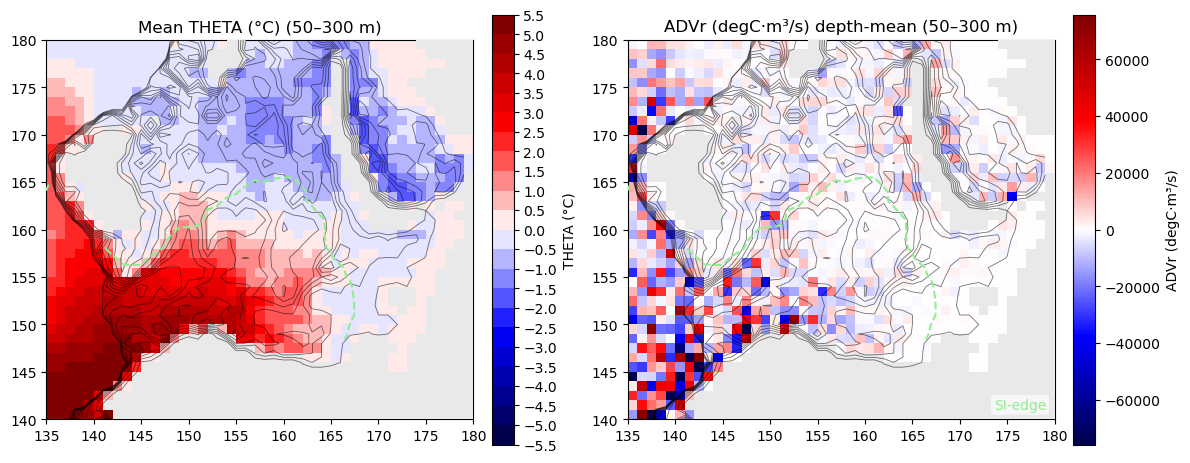

In [63]:
term_key = "ADVr"
fig, axes, out = plot_terms(
    tracer3d=THETA,
    terms3d=termsT3D,
    term_key=term_key,
    mygrid=mygrid, nfx=nfx, nfy=nfy,
    SI_contour=SI_contour, landmsk=landmsk, mymsk=mymsk,
    z1=50, z2=300,
    xlim=(135,180), ylim=(140,180),
    tracer_label="THETA (°C)",
    term_label=term_key + " (degC·m³/s)",
    tracer_center0=True,          # centers tracer colorbar at 0
)


## plot some of these for the SALT budget